# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Load Dataset

In [2]:
df = pd.read_csv(r"D:\ClimateGuardAI\datasets\engineered\climate_anomaly_engineered.csv")

print(df.head())

   latitude  longitude  temperature_celsius  wind_kph  wind_degree  \
0     24.57      77.72                 27.5      20.5          281   
1     23.33      77.80                 27.5      15.5          287   
2     22.07      78.93                 26.3      18.4          317   
3     21.86      77.93                 25.6      16.9          297   
4     22.75      77.72                 27.2      16.2          274   

   pressure_mb  precip_mm  humidity  cloud  feels_like_celsius  ...  \
0         1008        0.0        67     26                29.7  ...   
1         1008        0.0        70     19                30.0  ...   
2         1009        0.0        70     51                28.2  ...   
3         1009        0.0        76     65                27.6  ...   
4         1009        0.0        74     82                29.9  ...   

   day_period_Morning  day_period_Night  season_Monsoon  season_Post_Monsoon  \
0                 1.0               0.0             1.0                 

# Create Target Variable: rainfall_risk

In [3]:
def rainfall_category(x):
    if x == 0:
        return "Low"
    elif x <= 10:
        return "Medium"
    else:
        return "High"

df["rainfall_risk"] = df["precip_mm"].apply(rainfall_category)

print(df["rainfall_risk"].value_counts())

rainfall_risk
Low       104510
Medium     14829
High          59
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_5364\1436050008.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["rainfall_risk"] = df["precip_mm"].apply(rainfall_category)


# Feature Selection

In [4]:
features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'PM2.5',
    'PM10',
    'vis_km',
    'uv',
    'wind_kph'
]

features = [col for col in features if col in df.columns]

X = df[features]
y = df["rainfall_risk"]

# Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Model Training

## MODEL 1 : Logistic Regression

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

lr_search = RandomizedSearchCV(
    lr,
    lr_params,
    cv=3,
    scoring='accuracy',
    n_iter=5,
    random_state=42
)

lr_search.fit(X_train_scaled, y_train)
lr_best = lr_search.best_estimator_

d:\ClimateGuardAI\venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
9 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "d:\ClimateGuardAI\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\ClimateGuardAI\venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\ClimateGuardAI\venv\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1488, in fit
    raise ValueError(
  

## MODEL 2 : Gradient Boosting

In [8]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    gb,
    gb_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

gb_search.fit(X_train, y_train)
gb_best = gb_search.best_estimator_

print("Best Gradient Boosting Params:", gb_search.best_params_)


KeyboardInterrupt: 

## MODEL 3 : XGBoost

In [ ]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_train_encoded)),
    random_state=42,
    use_label_encoder=False
)

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train_encoded)
xgb_best = xgb_search.best_estimator_

print("Best XGB Params:", xgb_search.best_params_)

d:\ClimateGuardAI\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


# PREDICTIONS

In [ ]:
lr_pred = lr_best.predict(X_test_scaled)
gb_pred = gb_best.predict(X_test)
xgb_pred = xgb_best.predict(X_test)

# ACCURACY SCORES

In [ ]:
lr_acc = accuracy_score(y_test, lr_pred)
gb_acc = accuracy_score(y_test, gb_pred)
xgb_acc = accuracy_score(y_test_encoded, xgb_pred)

# Compare Models

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Accuracy': [
        lr_acc,
        gb_acc,
        xgb_acc
    ]
})

print("\nModel Comparison")
print(results)

best_model = results.loc[results['Accuracy'].idxmax()]

print("\nBest Model:")
print(best_model)


Model Comparison
                 Model  Accuracy
0  Logistic Regression  0.879983
1              XGBoost  0.894933


# FINAL PREDICTION REPORT

In [ ]:
if best_model['Model'] == 'Logistic Regression':
    final_pred = lr_pred

elif best_model['Model'] == 'Gradient Boosting':
    final_pred = gb_pred

else:
    final_pred = xgb_pred

print("\nClassification Report")
print(classification_report(y_test, final_pred, target_names=encoder.classes_))


# Predict New Sample

In [ ]:
sample = pd.DataFrame({
    'temperature_celsius': [30],
    'humidity': [85],
    'pressure_mb': [1005],
    'PM2.5': [40],
    'PM10': [60],
    'vis_km': [6],
    'uv': [7],
    'wind_kph': [15]
})

sample = sample[features]

if best_model['Model'] == 'Logistic Regression':
    sample_scaled = scaler.transform(sample)
    prediction = lr_best.predict(sample_scaled)
    risk = prediction[0]

elif best_model['Model'] == 'Gradient Boosting':
    prediction = gb_best.predict(sample)
    risk = prediction[0]

else:
    prediction = xgb_best.predict(sample)
    risk = encoder.inverse_transform(prediction)[0]

print("\nPredicted Rainfall Risk:", risk)



Best Model:
Model        XGBoost
Accuracy    0.894933
Name: 1, dtype: object


# SAVE ENGINEERED DATASET

In [ ]:
output_dir = r"D:\ClimateGuardAI\datasets\engineered"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "rainfall_risk_engineered.csv")
df.to_csv(output_path, index=False)

print("\nDataset saved at:", output_path)

# SAVE MODELS

In [ ]:
save_path = r"D:\ClimateGuardAI\backend\ml\artifacts"
os.makedirs(save_path, exist_ok=True)

# Save encoder
with open(os.path.join(save_path, 'rainfall_risk_label_encoder.pkl'), 'wb') as f:
    pickle.dump(encoder, f)

# Save scaler
with open(os.path.join(save_path, 'rainfall_risk_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

# Save best model
if best_model['Model'] == 'Logistic Regression':
    with open(os.path.join(save_path, 'rainfall_risk_logistic_regression.pkl'), 'wb') as f:
        pickle.dump(lr_best, f)

elif best_model['Model'] == 'Gradient Boosting':
    with open(os.path.join(save_path, 'rainfall_risk_gradient_boosting.pkl'), 'wb') as f:
        pickle.dump(gb_best, f)

else:
    with open(os.path.join(save_path, 'rainfall_risk_xgboost.pkl'), 'wb') as f:
        pickle.dump(xgb_best, f)

print("\nAll models saved successfully in:", save_path)


Predicted Rainfall Risk:
Low


# VISUALIZATION

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(
    x='rainfall_risk',
    data=df,
    order=df['rainfall_risk'].value_counts().index
)
plt.title("Distribution of Rainfall Risk Categories")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

<>:5: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:5: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_3316\2523126863.py:5: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  output_dir = "D:\ClimateGuardAI\datasets\engineered"



Rainfall risk dataset saved successfully at:
D:\ClimateGuardAI\datasets\engineered/rainfall_risk_engineered.csv


In [ ]:

save_path = "D:\ClimateGuardAI\backend\ml\artifacts"

os.makedirs(save_path, exist_ok=True)


# Save Label Encoder
with open(os.path.join(save_path,
                       'rainfall_risk_label_encoder.pkl'), 'wb') as file:
    pickle.dump(encoder, file)


# Save Scaler (used for Logistic Regression)
with open(os.path.join(save_path,
                       'rainfall_risk_scaler.pkl'), 'wb') as file:
    pickle.dump(scaler, file)


# Save Best Model
if best_model['Model'] == 'Logistic Regression':

    with open(os.path.join(save_path,
                           'rainfall_risk_logistic_regression.pkl'),
              'wb') as file:
        pickle.dump(lr, file)

    print("Saved: rainfall_risk_logistic_regression.pkl")


elif best_model['Model'] == 'Random Forest':

    with open(os.path.join(save_path,
                           'rainfall_risk_random_forest.pkl'),
              'wb') as file:
        pickle.dump(rf, file)

    print("Saved: rainfall_risk_random_forest.pkl")


else:

    with open(os.path.join(save_path,
                           'rainfall_risk_xgboost.pkl'),
              'wb') as file:
        pickle.dump(xgb, file)

    print("Saved: rainfall_risk_xgboost.pkl")


print("\nAll rainfall risk artifacts saved successfully.")
print("Files saved in:", save_path)

# Possible Outputs:
# Low
# Medium
# High


<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_3316\2436481996.py:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  save_path = "D:\ClimateGuardAI\backend\ml\artifacts"


OSError: [WinError 123] The filename, directory name, or volume label syntax is incorrect: 'D:\\ClimateGuardAI\x08ackend'

# Distribution of Rainfall Risk Categories

/tmp/ipykernel_12558/1322561362.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rainfall_risk', data=df, order=df['rainfall_risk'].value_counts().index, palette='viridis')


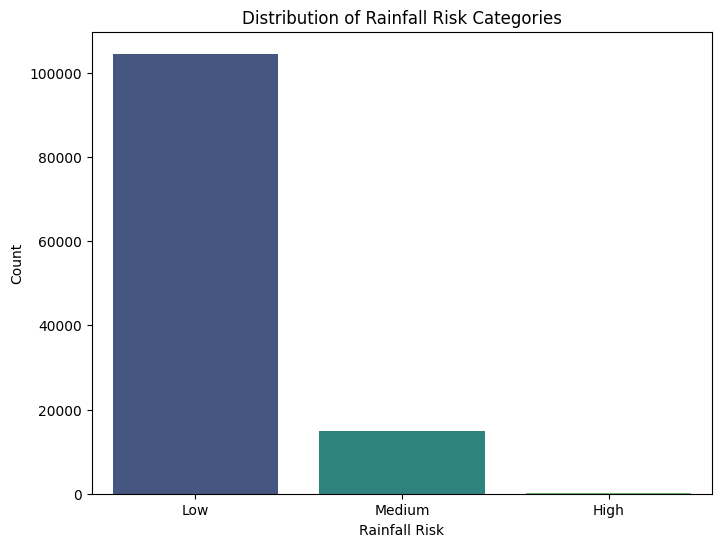

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize class imbalance
plt.figure(figsize=(8, 6))
sns.countplot(x='rainfall_risk', data=df, order=df['rainfall_risk'].value_counts().index, palette='viridis')
plt.title('Distribution of Rainfall Risk Categories')
plt.xlabel('Rainfall Risk')
plt.ylabel('Count')
plt.show()